In [1]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import rnn, cnn, encoder
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle


In [2]:
with open('pedestrian_behavior_or_trafficlight_state_cnn_model.pkl', 'rb') as f:
    cnn_traffic_behaviour = pickle.load(f)

In [3]:
path = 'C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-video-frames-labelled.dat'
data = np.memmap(path, dtype='float16', mode='r', shape=(3810, 5, 128, 128, 13))

X = cnn_traffic_behaviour.predict(data[:, :, :, :, :8])
y = data[:,0,0,0,12].reshape(-1,1) # Shape (N, 5), GPS speed

split = int(len(X) * .9)

X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

In [10]:
ann = encoder.Autoencoder(
    encoder = [
        nn.Flatten(),           # Changes (5, 7) to 35
        nn.Linear(35, 16),      # First reduction
        nn.ReLU(),
        nn.Linear(16, 8),      # First reduction
        nn.ReLU(),
        nn.Linear(8, 4)        # Final compressed size
    ],
    decoder = [
        nn.Linear(4, 8),        # Start expansion
        nn.ReLU(),
        nn.Linear(8, 16),       # Back to 16 values
        nn.ReLU(),
        nn.Linear(16, 35),      # Back to 35 values
        nn.Unflatten(1, (5, 7)) # Restores the (5, 7) shape
    ],
    epochs=1000,
    lr=1e-4,
    batch_size=100,
    device='cuda'
)

ann.fit(X_train)

Training: 100%|██████████| 35000/35000 [02:17<00:00, 254.50it/s, epoch=1000, loss=0.0067]


,encoder,"[Flatten(start...1, end_dim=-1), Linear(in_fea...16, bias=True), ...]"
,decoder,"[Linear(in_fea...=8, bias=True), ReLU(), ...]"
,epochs,1000
,lr,0.0001
,batch_size,100
,min_delta,0.0
,device,'cuda'
,seed,42


In [13]:
with open('scene_autoencoder_model.pkl', 'wb') as f:
    pickle.dump(ann, f)

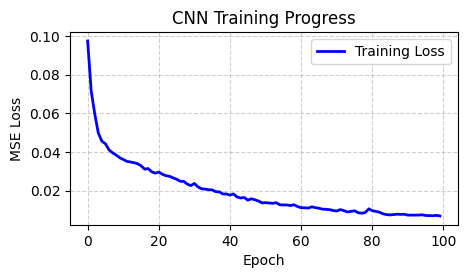

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 2.5))
plt.plot(cnn_traffic_behaviour.losses, label='Training Loss', color='blue', linewidth=2)
plt.title('CNN Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

<Axes: xlabel='0', ylabel='1'>

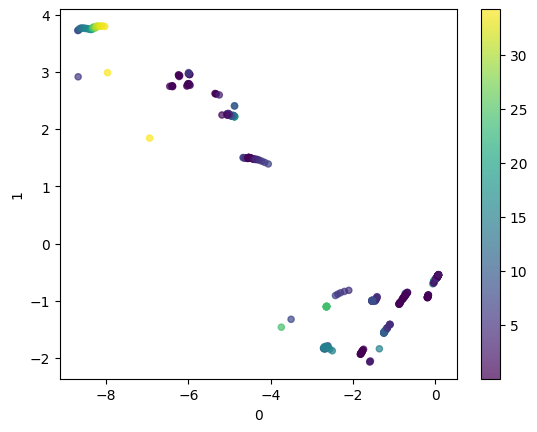

In [12]:
pd.DataFrame(ann.transform(X_test)).plot.scatter(x=0, y=1, alpha=0.7, c=y_test.flatten(), cmap='viridis')